<a href="https://colab.research.google.com/github/Perlangas28/Simulacion_2/blob/main/Ejercicio_Metr%C3%B3polis_Hastings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Simulación mediante el algoritmo de Metrópolis-Hastings

**Alumna: Perla Blancas Hernández**  
**Materia:** Simulación 2
**Prueba aplicada:** Algoritmo de Metrópolis-Hastings

El objetivo de este algoritmo es implementar mediante simulación el algoritmo de Metropolis-Hastings para generar muestras de una distribución de probabilidad bidimensional definida por la función objetivo $f(x_1,x_2)$.

Se busca analizar el comportamiento y la convergencia de diferentes cadenas de Markov iniciadas en distintos puntos, así como comprobar gráficamente que las muestras generadas por el algoritmo se concentran en las regiones donde la función objetivo presenta mayor densidad.


Para ello se utilizarán gráficas de las cadenas, un mapa de calor de la función objetivo y una representación de las muestras obtenidas mediante la simulación.


##EJERCICIO
Se desea simular mediante el algoritmo de Metropolis-Hastings una distribución de probabilidad bidimensional cuya función de densidad es proporcional a:

$$
f(x_1,x_2)=
C\exp\left[
-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2}
\right],
$$

Para realizar la simulación se utilizará una distribución propuesta normal, aprovechando que es una distribución simétrica. Por lo tanto, la probabilidad de aceptación se puede expresar como:

$$
\alpha(X,Y)=
\min\left\{
1,
\frac{\pi(Y)}{\pi(X)}
\right\}.
$$

Se generarán diferentes cadenas de Markov a partir de distintos valores iniciales para observar su comportamiento y analizar gráficamente su convergencia hacia la distribución objetivo.

## Metodología

Se utilizará el algoritmo de Metropolis-Hastings mediante una caminata aleatoria.

El procedimiento es el siguiente:

1. Se establece un punto inicial $X_0=(x_1,x_2)$.

2. Se genera un candidato $Y$ a partir de una distribución normal:

$$
Y \sim N(X_t,\sigma^2 I).
$$

3. Se calcula la probabilidad de aceptación:

$$
\alpha(X_t,Y)
=
\min\left\{
1,
\frac{\pi(Y)}{\pi(X_t)}
\right\}.
$$

4. Se genera un número aleatorio:

$$
U\sim U(0,1).
$$

5. Si:

$$
U\leq\alpha(X_t,Y),
$$

se acepta el candidato:

$$
X_{t+1}=Y.
$$

En caso contrario, se conserva el estado anterior:

$$
X_{t+1}=X_t.
$$

6. El procedimiento se repite durante un número determinado de iteraciones.

Las muestras obtenidas forman una cadena de Markov cuya distribución estacionaria corresponde a la distribución objetivo.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st


# ==========================================================
# FUNCIÓN OBJETIVO
# ==========================================================

def target(x):

    x1 = x[0]
    x2 = x[1]

    return np.exp(
        -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2
    )


# ==========================================================
# ALGORITMO METROPOLIS-HASTINGS
# ==========================================================

def metropolissampler(niters, x0, sigma):

    # Matriz donde guardaremos x1 y x2
    samples = np.zeros((niters + 1, 2))

    # Punto inicial
    x = np.array(x0, dtype=float)

    samples[0] = x

    aceptadas = 0

    for i in range(niters):

        # --------------------------------------------------
        # Paso 1: generar candidato
        # Y ~ N(Xt, sigma^2)
        # --------------------------------------------------

        x_p = x + np.random.normal(0, sigma, 2)

        # --------------------------------------------------
        # Paso 2: calcular probabilidad de aceptación
        # --------------------------------------------------

        fx = target(x)
        fx_p = target(x_p)

        alpha = min(1, fx_p / fx)

        # --------------------------------------------------
        # Paso 3: generar U ~ Uniforme(0,1)
        # --------------------------------------------------

        u = np.random.uniform()

        # --------------------------------------------------
        # Paso 4: aceptar o rechazar
        # --------------------------------------------------

        if u < alpha:
            x = x_p
            aceptadas += 1

        # Guardar estado de la cadena
        samples[i + 1] = x

    tasa_aceptacion = aceptadas / niters

    return samples, tasa_aceptacion


# ==========================================================
# SIMULACIÓN
# ==========================================================

niters = 50000
sigma = 0.5

# Tres puntos iniciales
puntos_iniciales = [
    [0.01, 0.01],
    [0.3, 0.3],
    [0.5, 0.5]
]

cadenas = []

for punto in puntos_iniciales:

    cadena, tasa = metropolissampler(
        niters,
        punto,
        sigma
    )

    cadenas.append(cadena)

    print(
        "Punto inicial:", punto,
        " | Tasa de aceptación:", round(tasa, 4)
    )

Punto inicial: [0.01, 0.01]  | Tasa de aceptación: 0.5239
Punto inicial: [0.3, 0.3]  | Tasa de aceptación: 0.5223
Punto inicial: [0.5, 0.5]  | Tasa de aceptación: 0.5167


##Gráfica de las cadenas de Markov

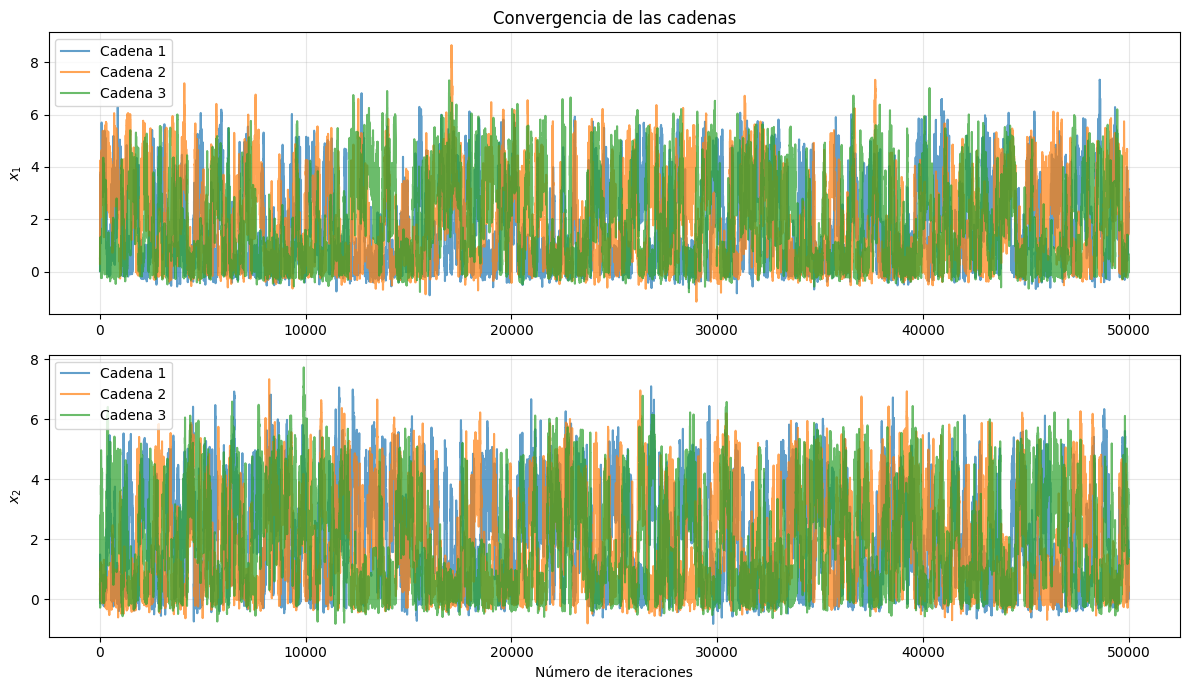

In [2]:
plt.figure(figsize=(12, 7))

for i in range(len(cadenas)):

    plt.subplot(2, 1, 1)
    plt.plot(
        cadenas[i][:, 0],
        alpha=0.7,
        label="Cadena " + str(i + 1)
    )

plt.ylabel("$x_1$")
plt.title("Convergencia de las cadenas")
plt.legend()
plt.grid(alpha=0.3)


plt.subplot(2, 1, 2)

for i in range(len(cadenas)):

    plt.plot(
        cadenas[i][:, 1],
        alpha=0.7,
        label="Cadena " + str(i + 1)
    )

plt.xlabel("Número de iteraciones")
plt.ylabel("$x_2$")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##Mapa de calor de la función

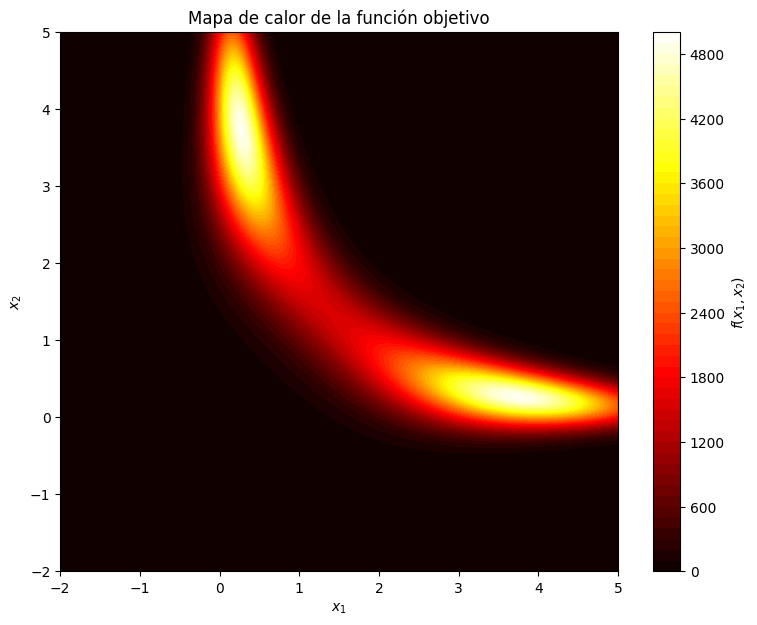

In [3]:
# ==========================================================
# MALLA PARA GRAFICAR LA FUNCIÓN
# ==========================================================

x1 = np.linspace(-2, 5, 300)
x2 = np.linspace(-2, 5, 300)

X1, X2 = np.meshgrid(x1, x2)

Z = np.exp(
    -(X1**2 * X2**2 + X1**2 + X2**2 - 8*X1 - 8*X2) / 2
)


# ==========================================================
# MAPA DE CALOR
# ==========================================================

plt.figure(figsize=(9, 7))

plt.contourf(
    X1,
    X2,
    Z,
    levels=50,
    cmap="hot"
)

plt.colorbar(label="$f(x_1,x_2)$")

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Mapa de calor de la función objetivo")

plt.show()

##Muestras del Metrópolis Hastings sobre el mapa

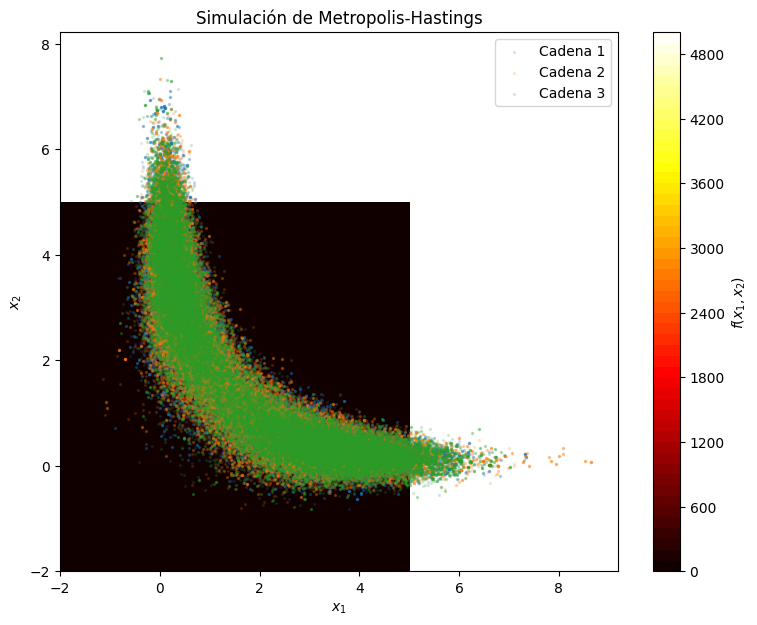

In [4]:
plt.figure(figsize=(9, 7))

# Función objetivo
plt.contourf(
    X1,
    X2,
    Z,
    levels=50,
    cmap="hot"
)

plt.colorbar(label="$f(x_1,x_2)$")

# Graficar las muestras
for i in range(len(cadenas)):

    plt.scatter(
        cadenas[i][5000:, 0],
        cadenas[i][5000:, 1],
        s=2,
        alpha=0.15,
        label="Cadena " + str(i + 1)
    )

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Simulación de Metropolis-Hastings")
plt.legend()

plt.show()

##Observamos la gráfica 3D

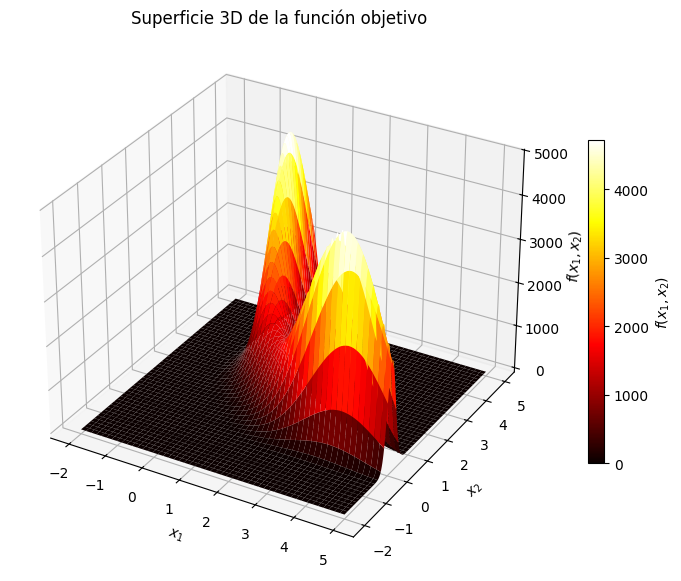

In [5]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

superficie = ax.plot_surface(
    X1,
    X2,
    Z,
    cmap="hot",
    edgecolor="none"
)

fig.colorbar(
    superficie,
    ax=ax,
    shrink=0.6,
    label="$f(x_1,x_2)$"
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$f(x_1,x_2)$")

ax.set_title("Superficie 3D de la función objetivo")

plt.show()

## Conclusión

La simulación permitió implementar el algoritmo de Metropolis-Hastings para obtener muestras de una distribución de probabilidad bidimensional cuya función de densidad es conocida únicamente hasta una constante de normalización.

A partir de diferentes valores iniciales se generaron cadenas de Markov y se analizó gráficamente su comportamiento. Las muestras obtenidas permiten observar cómo el algoritmo explora el espacio y se concentra en las regiones de mayor densidad de la distribución objetivo.

De esta manera, se comprueba mediante simulación el funcionamiento del algoritmo de Metropolis-Hastings y su capacidad para generar muestras de distribuciones para las cuales la simulación directa puede resultar complicada.